## 1. Introduction
This project investigates the motion of a simple pendulum using mathematical modelling and numerical simulation. The project begins with an idealised pendulum and progressively introduces damping to investigate its effect on the motion.

## 2. Assumptions
- The string suspending the pendulum has zero mass
- The pendulum is modelled as a point mass
- The length of the string is constant. It doesn't stretch go slack
- The gravitational field is uniform, so the gravitational acceleration $g$ is constant.
- The pivot point is fixed
- There is no friction between the pivot and the string

## 3. Equation of Motion for a Simple Pendulum ( no damping )
First, I will model an idealised pendulum. This neglects air resistance and other resistive forces.
By considering the tangential direction of the pendulum's motion, we define $ F $ to be the net force acting tangential to the pendulum, and $ \theta $ to be the angular displacement from the pendulum's equilibrium position, measured in radians. ($ \theta > 0 $ represents a clockwise angle, and $ \theta < 0 $ represents an anticlockwise angle) $ g $ is gravitational acceleration, $ m $ is the mass of the pendulum, and $ L $ is the length of the string.

Gravitational force is given by

$ F = mg $

The component of gravitational force acting tangetially to the pendulum has magnitude

$ mg\sin(\theta) $

For a positive angular displacement, the tangential component of gravity
acts in the opposite direction to the displacement. Therefore,

$ F_{tan} = -mg\sin(\theta) $

To get an expression for $ F $ in terms of $ \theta $ we consider the relationship between arc length and angular displacement

$ s = L\theta $

where $ s $ denotes arc length in the clockwise direction, and $ a $ represents the acceleration tangential to the pendulum.
Then by differentiating twice, we get

$ \ddot{s} = L \ddot{\theta} $

$ a_{tan} = L \ddot{\theta} $

By applying Newton's Second Law in the tangential direction,

$ F_{tan} = m a_{tan} $

Therefore, $ F = mL \ddot{\theta} $

Substituting the expressions for the tangential force and acceleration,

$ mL \ddot{\theta} = -mg\sin(\theta) $

This is the equation of motion of a simple pendulum

$$\boxed{ \ddot{\theta} = -\frac{g}{L}\sin(\theta) }$$

### 3.1 Small Angle Approximation

For small values of $ \theta $ , $ \sin(\theta) $ can be approximated with $ \theta $, and the equation now looks like this

$ \ddot{\theta} = -\frac{g}{L}\theta $

This equatiopn

This equation has the same form as the equation of simple harmonic motion,

$ \ddot{x} + k^2x = 0. $

The general solution to this second order linear ODE is

$ x = A\sin(k t) + B\cos(k t) $
for some constants $ A $, $ B $, depending on the initial conditions.

Therefore, for small angular displacements, the motion of a simple
pendulum can be approximated as simple harmonic motion with

$ k = \sqrt{\frac{g}{L}}.$

and has general solution
$ \theta = A\sin(\sqrt{\frac{g}{L}} t) + B\cos(\sqrt{\frac{g}{L}} t) $


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
L = 1.0   # length of the pendulum (m)
g = 9.81  # acceleration due to gravity (m/s^2)

theta_0 = np.radians(30)  # initial angle (30 degrees converted to radians)
omega_0 = 0.0  # initial angular velocity (rad/s)

coefficients = np.array([
    [1, 0],
    [0, np.sqrt(g / L)]
])

initial_conditions = np.array([
    theta_0,
    omega_0
])

x = np.linalg.solve(coefficients, initial_conditions)
A = x[0]
B = x[1]

print("A is:", A)
print("B is:", B)

t=np.linspace(0, 10, 1000)  # time array from 0 to 10 seconds

A is: 0.5235987755982988
B is: 0.0


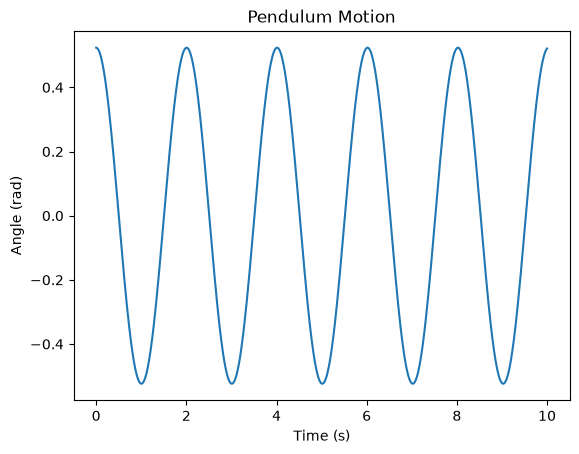

In [3]:
plt.plot(t, A * np.cos(np.sqrt(g / L) * t) + B * np.sin(np.sqrt(g / L) * t))
plt.title("Pendulum Motion")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.show()


## 4. Numerical Method
$$ \boxed{ \ddot{\theta} = -\frac{g}{L}\sin(\theta) }$$
For larger values of $ \sin{\theta} $, $ \sin{\theta} $ cannot be approxiamted with $ \theta $. However, this ODE has no closed form solution,as it is a non-linear ODE due to the sine function. 
So, we will implement a numerical method to solve this ODE as it is easy to estimate its path

### 4.1 Euler's Method
The pendulum has to be rewritten as two first-order differential equations, one in terms of angular displacement, and one in terms of angular velocity. Let angular velocity be denoted by $ \omega $.

$ \omega  = \dot{\theta} $ and
$ \dot{\omega} = \ddot{\theta} $

We now have $ \dot{\omega} = -\frac{g}{L}\sin(\theta) $

Using Euler's Method, we have that
$$ \theta_{n+1} = \theta_{n} + \Delta t (\omega_{n}) $$

$$ \omega_{n+1} = \omega_{n} + \Delta t (\ddot{\theta_{n}}) $$
$$ \omega_{n+1} = \omega_{n} + \Delta t (-\frac{g}{L}\sin(\theta_{n})) $$

This creates an interative process using known values of $ \omega $ and $ \theta $ to estimate their next respective values, where $ \Delta t $ represents a small change in time, the difference in time between successive measurements of $ \omega $ and $ \theta $. The smaller the value of $ \Delta t $ the more accurate the estimates are.

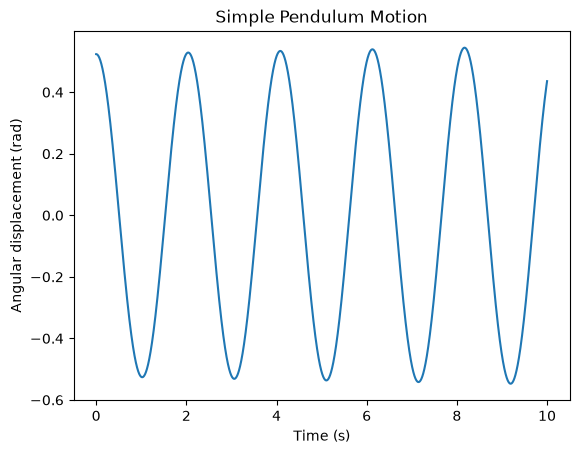

In [4]:
L = 1.0   # length of the pendulum (m)
g = 9.81  # acceleration due to gravity (m/s^2)

theta_0 = np.radians(30)  # initial angle (30 degrees converted to radians)
omega_0 = 0.0  # initial angular velocity (rad/s)
t_max = 10000  # number of time steps

t = np.linspace(0, 10, t_max)  # time array from 0 to 10 seconds with t_max points
dt = t[1] - t[0]  # time step size 

theta = np.zeros(len(t))    # array to store angular displacement values
omega = np.zeros(len(t))    # array to store angular velocity values

theta[0] = theta_0 
omega[0] = omega_0  

for n in range(len(t) - 1):
    theta[n + 1] = theta[n] + omega[n] * dt
    omega[n + 1] = omega[n] - (g / L) * np.sin(theta[n]) * dt

# Plotting the results  
plt.plot(t, theta) 

plt.xlabel("Time (s)") 
plt.ylabel("Angular displacement (rad)")
plt.title("Simple Pendulum Motion")

plt.show()

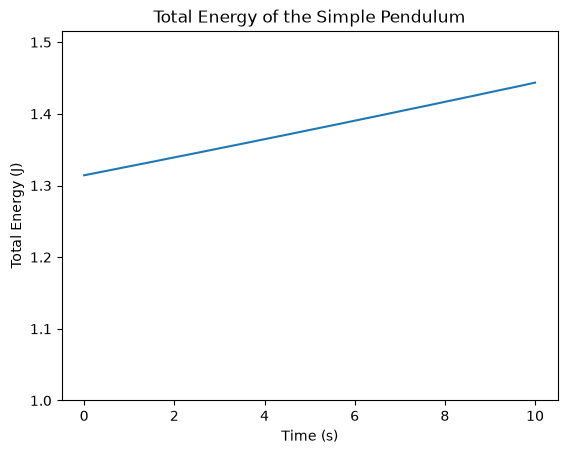

In [5]:
# Checking the energy of the pendulum
# Calculating the kinetic and potential energy
KE = 0.5 * (L**2) * (omega**2)
PE = g * L * (1 - np.cos(theta))
# Total energy
E_total = KE + PE

plt.plot(t, E_total)
plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Total Energy of the Simple Pendulum")
plt.ylim(1, np.max(E_total) * 1.05)  # Set y-axis limits for better visualization
plt.show()

### 4.2 Increase in Total Energy

The graph of the simple pendulum in an ideal setting should follow a sine wave, however, using Euler's Method, it seems to create a wave with amplitude increasing over time, and so does the total energy of the system. 
This is because Total Energy = Kinetic Energy + Potential Energy which is equal to 
$ \frac{1}{2} m v^2 + m g h  $

Similar to the method of expressing $ F_{tan} $ in terms of $ \theta $, we start with

$ s = L\theta $

where $ s $ denotes arc length in the clockwise direction, and $ a $ represents the acceleration tangential to the pendulum.
Then by differentiating once, we get

$ \dot{s} = L \dot{\theta} $

$ v = L \omega $

The Kinetic Energy of the system, $ K $ is represented as 
$$ K = \frac{1}{2} m {L \omega }^2 = \frac{1}{2} m {L}^2 {\omega}^2 $$

Therefore, the Total Energy is equal to $$ \frac{1}{2} m {L}^2 {\omega}^2  + m g h $$

The only variables being manipulated is $ \theta $ and $ \omega $ so seems to be that an overestimation of $ \omega $ could be leading to an increase in energy over time.

Eulers' Method says that $ \theta_{n+1} = \theta_n + \omega_n \Delta t $, which assumes that $ \omega_n $ stays constant in this $ \Delta t $  interval. However, $ \omega $ is continuosly changing because $ \dot{\omega}  = -\frac{g}{L}\sin(\theta) $. If $ \omega $ were to be constant, $ \dot{\omega} $ should be equal to 0, which it isn't. This explains why the amnplitude of the waves seems to be increasing, and consequently the total energy. 

### 4.3 Why choosing a smaller $ \Delta t $ makes for a better approximation 

Taylor Series of a function at some real number,$ a $

$$ f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a) + ... = \sum_{n=0}^{\infty} \frac{f^n(a)}{n!}(x-a)^n$$

Let $ x = t + \Delta t $ and evaluate at $ a = t $. Then,
$$ \theta(t + \Delta t) = \theta(t) + \dot{\theta}(t)(\Delta t) +\frac{\ddot{\theta}(t)}{2!}(\Delta t)^2  + ... $$

Euler's Method says that $$ \theta(t + \Delta t) \approx \theta(t) + \dot{\theta}(t)(\Delta t) $$
This leaves out the terms behind which are proportional to powers of $ \Delta t $. The error is $ \frac{\ddot{\theta}(t)}{2!}(\Delta t)^2  + ...  $

Therefore, by choosing smaller values of $ \Delta t $, the error gets smaller.

________________________________________________________________________________________________________________________________________________

 Note: Taylor Series requires that $ \theta (t) $ is infinitely differentiable. It is because of the relationship 

$ \ddot{\theta} = -\frac{g}{L}\sin(\theta) $

$ \theta''(t) = -\frac{g}{L}\sin(\theta(t)) $

$ \theta $ is continuous, and $ \ddot{\theta} $ is continuous because sine and $ \theta $ are continuos. So $ \theta $ is at least twice differentiable.
Notice that the right hand side is differentiable, so

$ \theta^{(3)} (t)=  -\frac{g}{L}\cos(\theta(t)) \theta'(t) $
and in general $ \theta^{(n)}(t) $ exists for all $ n $ because sin and cos are infinitely differentiable, along with the lower derivatives already establised to exist.


## 5. A Damped Pendulum
In this section, we will investigate the model for two types of damping. Linear, and quadratic damping.

### 5.1 Linear Damping 
In this model, it is assumed that the damping is due only to drag/ air resistance, and opposes the pendulum's motion. Hence, it is a force that acts tangential but opposite to the motion of the pendulum.
The drag force, $ F_d $ is assumed to be proportional to velocity. $$ F_d = bv $$ where $ b $ is a positive constant called a _damping coefficient_, and $ v $ is the tangential velocity of the pendulum.

From section 4.2, we have

$ s = L\theta $

$ \dot{s} = L \dot{\theta} $

$ v = L \omega $
Since drag force acts opposite in direction to the direction of motion, $$ F_d = -b L \omega = -bL\dot{\theta} $$ 

In the idealised case, $$ mL \ddot{\theta} = -mg\sin(\theta) $$
When introducing the damping factor, $$ \boxed{ mL \ddot{\theta} = -mg\sin(\theta) - bL\dot{\theta} }$$ 

Again, by taking
$ \omega  = \dot{\theta} $ and
$ \dot{\omega} = \ddot{\theta} $

$$ \boxed{ mL \dot{\omega} = -mg\sin(\theta) - bL\omega } $$

We now have $$ \ddot{\theta}_n = \dot{\omega}_n = -\frac{g}{L}\sin(\theta_{n}) -\frac{b}{m}\omega_n $$

Using Euler's Method, we have that
$$ \theta_{n+1} = \theta_{n} + \Delta t (\omega_{n}) $$

$$ \omega_{n+1} = \omega_{n} + \Delta t (\ddot{\theta}_n) $$
$$ \omega_{n+1} = \omega_{n} + \Delta t (-\frac{g}{L}\sin(\theta_{n}) -\frac{b}{m}\omega_n) $$



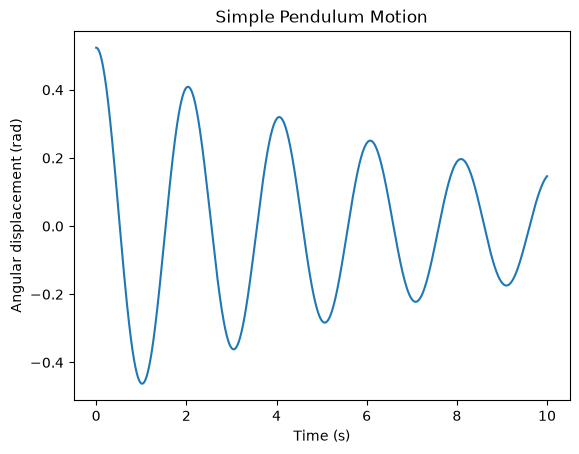

In [6]:
L = 1.0   # length of the pendulum (m)
g = 9.81  # acceleration due to gravity (m/s^2)
b= 0.25  # damping coefficient (kg/s)

theta_0 = np.radians(30)  # initial angle (30 degrees converted to radians)
omega_0 = 0.0  # initial angular velocity (rad/s)
t_max = 10000  # number of time steps

t = np.linspace(0, 10, t_max)  # time array from 0 to 10 seconds with t_max points
dt = t[1] - t[0]  # time step size 

theta = np.zeros(len(t))    # array to store angular displacement values
omega = np.zeros(len(t))    # array to store angular velocity values

theta[0] = theta_0 
omega[0] = omega_0  

for n in range(len(t) - 1):
    theta[n + 1] = theta[n] + omega[n] * dt
    omega[n + 1] = omega[n] + dt * (-(g / L) * np.sin(theta[n]) - b * omega[n])

# Plotting the results  
plt.plot(t, theta) 

plt.xlabel("Time (s)") 
plt.ylabel("Angular displacement (rad)")
plt.title("Simple Pendulum Motion")

plt.show()

### 5.2 Small Angle Approximation
For small values of $ \theta $ , $ \sin(\theta) $ can be approximated with $ \theta $. $ \sin(\theta) \approx \theta $.

Therefore, the new equation of motion is
$$  mL \ddot{\theta} = -mg\theta - bL\dot{\theta}  $$
$$ \ddot{\theta} + \frac{b}{m}\dot{\theta} + \frac{g}{L}\theta = 0 $$
This is a homogeneous second-order linear differential equation, which has a characteristic equation
$$ \lambda^2 + \frac{b}{m}\lambda + \frac{g}{L} = 0 $$
which has roots $ \lambda_1 = -\frac{b}{2m} + \frac{1}{2} \sqrt{ \frac{b^2}{m^2} - \frac{4g}{L}} $, $ \lambda_2 = -\frac{b}{2m} - \frac{1}{2} \sqrt{ \frac{b^2}{m^2} - \frac{4g}{L}} $

#### 5.2.1 Overdamping 
If $ \frac{b^2}{m^2} - \frac{4g}{L} > 0 $, the pendulum system is _overdamped_. The characteristic equation has two real and distinct roots. This is the general solution to the differential equation, with constants $ c_1 $, $ c_2 $ depending on initial conditions: 
$$ \theta(t) = c_1 e^{\lambda_1 t} + c_2 e^{\lambda_2 t} $$
Here, $ \lambda_1 $, $ \lambda_2 < 0 $, so $\theta$ approaches zero as time increases, but doesn't reach it as the exponential components have horizontal asymptotes at 0. 

#### 5.2.2 Critical Damping
If $ \frac{b^2}{m^2} - \frac{4g}{L} = 0 $, the pendulum system is _critically damped_. The characteristic equation has two equal, real roots, $\lambda_c $.  This is the general solution to the differential equation:
$$ \theta(t) = c_1 e^{\lambda_c t} + c_2 t e^{\lambda_c t} $$
Similar to overdamping, $ \lambda_1 $, $ \lambda_2 < 0 $, so $\theta$ approaches zero as time increases, but doesn't reach it as the exponential components have horizontal asymptotes at 0. However, critical damping does approach 0 faster than overdamping does. This is because $\lambda_c < \lambda_1 < 0 $.
So,  $0< e^{\lambda_c t} < e^{\lambda_1 t} $. The exponent containing $\lambda_c t $ will approach 0 faster than the exponent containing $ \lambda_1 t $

#### 5.2.3 Underdamping
If $ \frac{b^2}{m^2} - \frac{4g}{L} < 0 $, the pendulum system is _under damped_. The characteristic equation has two complex roots. This is the general solution to the differential equation:
$$ \theta(t) = c_1 e^{\alpha t} \cos(\beta t) + c_2 e^{\alpha t} \sin(\beta t) = e^{\alpha t} (c_1 \cos(\beta t) + c_2 \sin(\beta t))$$
where $ \alpha = Re(\lambda_1)=-\frac{b}{2m}, \beta = Im(\lambda_1)= \frac{1}{2} \sqrt{ |\frac{b^2}{m^2} - \frac{4g}{L}|}$
This has the same form as the general solution to the idealised pendulum in Section 3.1, just with an added scalar of $e^{\alpha t}$, which is called the _damping factor_. $ e^{\alpha t} $ decays over time, causing the amplitudes of the oscillations to decrease over time. $ e^{\alpha t} = e^{-\frac{b}{2m} t} $, which tells us that the greater the damping coefficient the faster the decay of the oscillations.

c_1 is: 0.5235987755982988
c_2 is: 0.0209131894329786


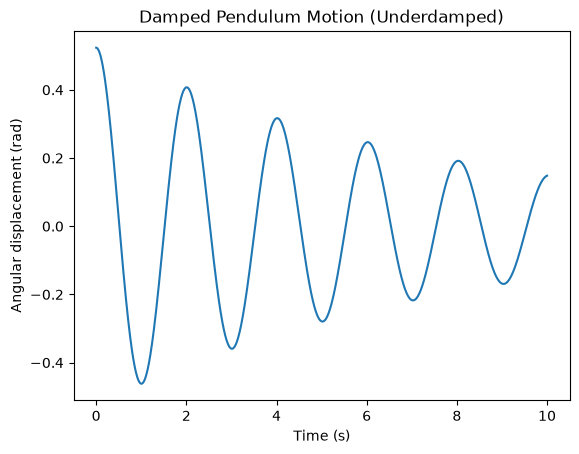

In [7]:
R = -b / (2 * L)
D  = b**2 / (4 * L**2) - g / L

t=np.linspace(0, 10, 1000)  # time array from 0 to 10 seconds

if D > 0:
    coefficients = np.array([
    [1, 1],
    [(R+np.sqrt(D)), R-np.sqrt(D)]
    ])

    initial_conditions = np.array([
    theta_0,
    omega_0
    ])

    x = np.linalg.solve(coefficients, initial_conditions)
    c_1 = x[0]
    c_2 = x[1]

    print("c_1 is:", c_1)
    print("c_2 is:", c_2)
    

    plt.plot(t, c_1 * np.exp((R + np.sqrt(D)) * t) + c_2 * np.exp((R - np.sqrt(D)) * t))

    plt.xlabel("Time (s)") 
    plt.ylabel("Angular displacement (rad)")
    plt.title("Damped Pendulum Motion (Overdamped)")

    plt.show()
elif D == 0:
    coefficients = np.array([
    [1, 0],
    [R, 1]
    ])

    initial_conditions = np.array([
    theta_0,
    omega_0
    ])

    x = np.linalg.solve(coefficients, initial_conditions)
    c_1 = x[0]
    c_2 = x[1]

    print("c_1 is:", c_1)
    print("c_2 is:", c_2)

    plt.plot(t, (c_1 + c_2 * t) * np.exp(R * t))

    plt.xlabel("Time (s)") 
    plt.ylabel("Angular displacement (rad)")
    plt.title("Damped Pendulum Motion (Critically Damped)")

    plt.show()
else: 
    coefficients = np.array([
    [1, 0],
    [R, np.sqrt(-D)]
    ])

    initial_conditions = np.array([
    theta_0,
    omega_0
    ])

    x = np.linalg.solve(coefficients, initial_conditions)
    c_1 = x[0]
    c_2 = x[1]

    print("c_1 is:", c_1)
    print("c_2 is:", c_2)

    plt.plot(t, np.exp(R * t) * (c_1 * np.cos(np.sqrt(-D) * t) + c_2 * np.sin(np.sqrt(-D) * t)))

    plt.xlabel("Time (s)") 
    plt.ylabel("Angular displacement (rad)")
    plt.title("Damped Pendulum Motion (Underdamped)")

    plt.show()